In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 16.0 MB/s eta 0:00:00


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem

# 测试一个简单分子
mol = Chem.MolFromSmiles('CCO')  # 乙醇
print("RDKit is working! Number of atoms:", mol.GetNumAtoms())

RDKit is working! Number of atoms: 3


In [4]:
from google.colab import drive
drive.mount('/content/drive/')
train_file = "/content/drive/MyDrive/SDSC6002/ci0c00102_si_002.xlsx"
test_file = "/content/drive/MyDrive/SDSC6002/ci0c00102_si_003.xlsx"

Mounted at /content/drive/


In [ ]:
# # Run if connection to GoogleDrive is not available
# from google.colab import files

# # 上传训练集
# print("Upload training dataset (805 compounds):")
# uploaded_train = files.upload()

# # 上传测试集
# print("Upload external test dataset (70 compounds):")
# uploaded_test = files.upload()
# # 假设你上传的文件名如下（请根据实际文件名修改）
# train_file = list(uploaded_train.keys())[0]  # 如 'dataset_805.xlsx'
# test_file = list(uploaded_test.keys())[0]    # 如 'ci0c00102_si_003.xlsx'

Upload training dataset (805 compounds):


Saving ci0c00102_si_002.xlsx to ci0c00102_si_002.xlsx
Upload external test dataset (70 compounds):


Saving ci0c00102_si_003.xlsx to ci0c00102_si_003.xlsx


In [5]:
import pandas as pd


df_train = pd.read_excel(train_file)
df_test = pd.read_excel(test_file)

print("Training set shape:", df_train.shape)   # 应为 (805, ...)
print("Test set shape:", df_test.shape)        # 应为 (70, ...)

# 查看关键列
print("\nTraining columns:", df_train.columns.tolist())
print("\nSample LogHD50 values:")
print(df_train[['SMILES', 'LogHD50']].head())

Training set shape: (805, 5)
Test set shape: (70, 5)

Training columns: ['#Name', 'LogHD50', 'Co-solvent', 'SMILES', 'Reference']

Sample LogHD50 values:
                                              SMILES  LogHD50
0  O=C(c1c([H])c(c([H])c([H])c1[H])C(=O)N([H])c2c...    1.146
1  O=C(c1c([H])c(c(OC([H])([H])[H])c([H])c1OC([H]...    2.161
2  O=C(c1c([H])c(c([H])c(OC([H])([H])C([H])([H])N...    2.037
3  O=C(c1c([H])c(c([H])c(OC([H])([H])C([H])([H])N...    1.987
4  O=C(c1nc([H])nc(c1[H])C(=O)N([H])c2c([S]C([H])...    1.786


In [6]:
# 1. 删除 HD50 为 NaN 或无效值的行
df_train = df_train.dropna(subset=['LogHD50', 'SMILES'])
df_test = df_test.dropna(subset=['LogHD50', 'SMILES'])
print("Training set shape (step 1):", df_train.shape)
print("Test set shape (step 1):", df_test.shape)

# 2. 确保 SMILES 有效（稍后用 RDKit 过滤）
# 3. 检查 LogHD50 是否为数值
df_train['LogHD50'] = pd.to_numeric(df_train['LogHD50'], errors='coerce')
df_test['LogHD50'] = pd.to_numeric(df_test['LogHD50'], errors='coerce')

# 再次删除无效行
df_train = df_train.dropna(subset=['LogHD50'])
df_test = df_test.dropna(subset=['LogHD50'])

print("After cleaning (step 2):")
print("Train:", df_train.shape)
print("Test:", df_test.shape)

Training set shape (step 1): (805, 5)
Test set shape (step 1): (70, 5)
After cleaning (step 2):
Train: (805, 5)
Test: (70, 5)


In [8]:
import numpy as np
import pandas as pd

# from rdkit import Chem
# from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# 创建一次生成器（可重复使用）
morgan_gen = GetMorganGenerator(radius=3, fpSize=2048)

def robust_mol_from_smiles(smiles):
    if not isinstance(smiles, str) or smiles == "":
        return None
    # === 新增：修复硝基 ===
    smiles = smiles.replace('N(=O)O', '[N+](=O)[O-]')
    smiles = smiles.replace('N(=O)[O]', '[N+](=O)[O-]')  # 备用格式
    # # 季铵盐：最常见模式 N(C)(C)(C)C → [N+](C)(C)(C)C
    # smiles = smiles.replace('N(C)(C)(C)C', '[N+](C)(C)(C)C')
    # smiles = smiles.replace('N(C)(C)(C)CC', '[N+](C)(C)(C)CC')
    # smiles = smiles.replace('N(CC)(CC)(CC)C', '[N+](CC)(CC)(CC)C')

    # 第一次尝试：标准解析（带完整 sanitization）
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return mol

    # 第二次尝试：关闭 sanitization，再手动修复（跳过凯库勒化）
    mol = Chem.MolFromSmiles(smiles, sanitize=False)
    if mol is None:
        return None

    try:
        # 执行除凯库勒化外的所有净化步骤
        Chem.SanitizeMol(
            mol,
            sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL ^ Chem.SanitizeFlags.SANITIZE_KEKULIZE
        )
        return mol
    except:
        return None

def smiles_to_ecfp6_with_failures(smiles_list, original_indices=None):  # ← 新增参数 original_indices
    if original_indices is None:
        original_indices = list(range(len(smiles_list)))  # ← 新增：默认索引

    fps = []
    valid_idx = []
    failed_smiles = []      # ← 新增：记录失败的 SMILES
    failed_original_idx = [] # ← 新增：记录原始索引

    for i, smi in enumerate(smiles_list):
        mol = robust_mol_from_smiles(smi)
        if mol is not None:
            try:
                fp = morgan_gen.GetFingerprint(mol)
                fps.append(fp)
                valid_idx.append(i)
            except Exception as e:  # ← 可选：捕获具体异常
                # 指纹生成失败 → 记录
                failed_smiles.append(smi)
                failed_original_idx.append(original_indices[i])  # ← 使用原始索引
        else:
            # 分子解析失败 → 记录
            failed_smiles.append(smi)
            failed_original_idx.append(original_indices[i])  # ← 使用原始索引

    return np.array(fps), valid_idx, failed_smiles, failed_original_idx  # ← 新增两个返回值


# 提取 SMILES 和原始索引（Excel 行号 = index + 2，因为 header 占 1 行）
smiles_train = df_train['SMILES'].tolist()
smiles_test = df_test['SMILES'].tolist()

# 原始索引（用于定位 Excel 中的行号）
train_original_indices = df_train.index.tolist()  # 通常是 0,1,2,...804
test_original_indices = df_test.index.tolist()    # 通常是 0,1,2,...69

# 生成指纹 + 记录失败样本
X_train, train_valid_idx, failed_train_smiles, failed_train_idx = smiles_to_ecfp6_with_failures(
    smiles_train, train_original_indices
)
X_test, test_valid_idx, failed_test_smiles, failed_test_idx = smiles_to_ecfp6_with_failures(
    smiles_test, test_original_indices
)

# 同步标签
y_train = df_train['LogHD50'].values[train_valid_idx]
y_test = df_test['LogHD50'].values[test_valid_idx]

print("✅ Training features shape:", X_train.shape)
print("✅ Test features shape:", X_test.shape)
print(f"⚠️ Failed in training set: {len(failed_train_smiles)} samples")
print(f"⚠️ Failed in test set: {len(failed_test_smiles)} samples")

# ----------------------------
# 可选：保存失败样本到 CSV（方便人工核查）
# ----------------------------

# 训练集失败样本
if failed_train_smiles:
    failed_train_df = df_train.iloc[failed_train_idx].copy()
    failed_train_df.to_csv("failed_samples_train.csv", index=False)
    print("📁 Saved failed training samples to 'failed_samples_train.csv'")

# 测试集失败样本
if failed_test_smiles:
    failed_test_df = df_test.iloc[failed_test_idx].copy()
    failed_test_df.to_csv("failed_samples_test.csv", index=False)
    print("📁 Saved failed test samples to 'failed_samples_test.csv'")

# 保存成功处理的样本（仅原始数据列，不含高维指纹）
df_train.iloc[train_valid_idx].to_csv("success_samples_train.csv", index=False)
df_test.iloc[test_valid_idx].to_csv("success_samples_test.csv", index=False)
print("✅ Saved successful samples to CSV files")


[02:17:33] Explicit valence for atom # 13 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 22 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 35 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 58 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 16 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 43 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 16 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 42 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 14 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 36 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 16 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 42 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom # 18 N, 4, is greater than permitted
[02:17:33] Explicit valence for atom #

✅ Training features shape: (624, 2048)
✅ Test features shape: (70, 2048)
⚠️ Failed in training set: 181 samples
⚠️ Failed in test set: 0 samples
📁 Saved failed training samples to 'failed_samples_train.csv'
✅ Saved successful samples to CSV files


In [ ]:
#没有CV也没有划分验证集出来，直接训练
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge

# 训练 Random Forest
# model = KernelRidge(kernel='rbf', alpha=0.1, gamma=0.01)
# model = SVR(kernel='rbf', C=5, gamma=0.01)
model = RandomForestRegressor(n_estimators=1000, random_state=42)
# model = XGBRegressor(n_estimators=1000, random_state=42)
# model = XGBRegressor(
#     n_estimators=1000,
#     max_depth=3,          # 降低树深度
#     learning_rate=0.01,   # 降低学习率
#     subsample=0.7,        # 随机采样样本
#     colsample_bytree=0.7, # 随机采样特征
#     reg_alpha=1.0,        # L1 正则
#     reg_lambda=2.0,       # L2 正则
#     random_state=42
# )
model.fit(X_train, y_train)

# 预测外部测试集
y_pred = model.predict(X_test)

# 评估
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.8051533700414006
MAE: 0.2980407808910949


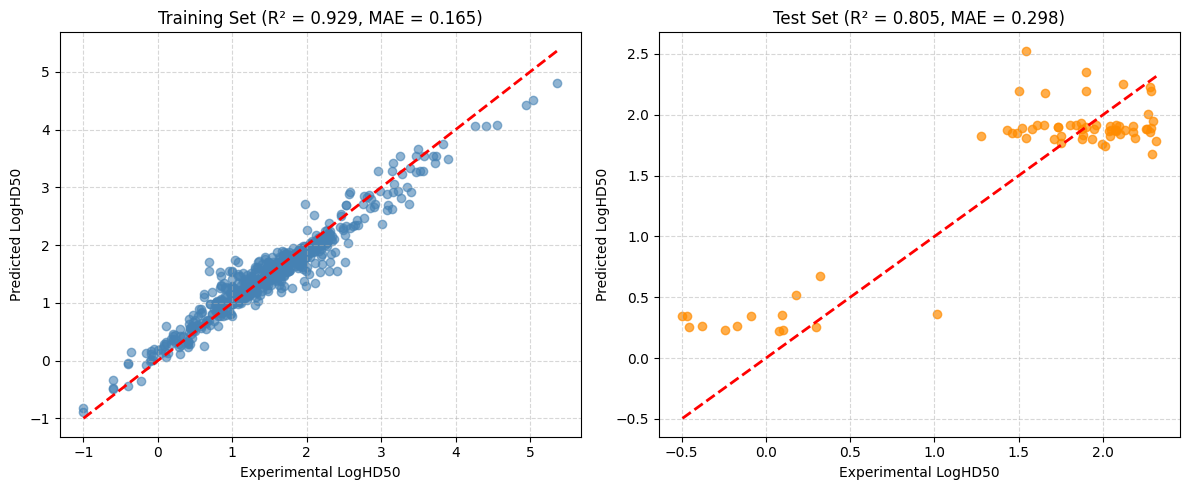

Training Set - R²: 0.929, MAE: 0.165
Test Set - R²: 0.805, MAE: 0.298


In [ ]:
# 预测训练集和测试集
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# 计算指标
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 训练集散点图
ax1.scatter(y_train, y_train_pred, alpha=0.6, color='steelblue')
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
ax1.set_xlabel('Experimental LogHD50')
ax1.set_ylabel('Predicted LogHD50')
ax1.set_title(f'Training Set (R² = {train_r2:.3f}, MAE = {train_mae:.3f})')
ax1.grid(True, linestyle='--', alpha=0.5)

# 测试集散点图
ax2.scatter(y_test, y_test_pred, alpha=0.7, color='darkorange')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Experimental LogHD50')
ax2.set_ylabel('Predicted LogHD50')
ax2.set_title(f'Test Set (R² = {test_r2:.3f}, MAE = {test_mae:.3f})')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 打印数值结果
print(f"Training Set - R²: {train_r2:.3f}, MAE: {train_mae:.3f}")
print(f"Test Set - R²: {test_r2:.3f}, MAE: {test_mae:.3f}")

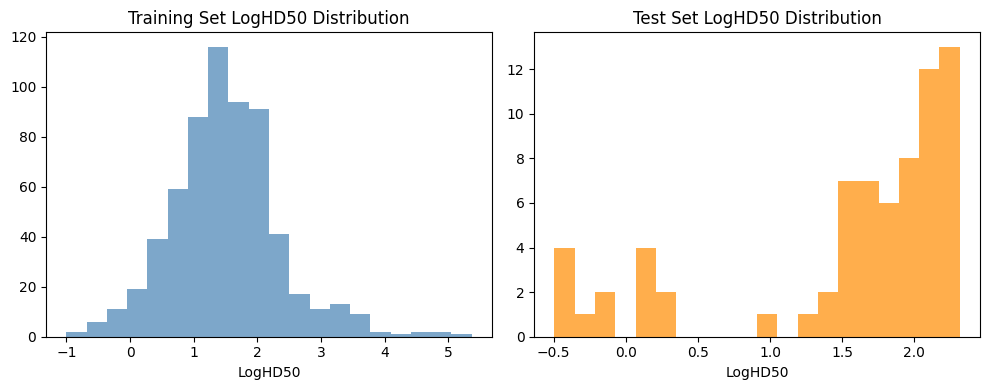

Training LogHD50 range: -1.00 ~ 5.37
Test LogHD50 range: -0.49 ~ 2.32


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# 训练集分布
plt.subplot(1, 2, 1)
plt.hist(y_train, bins=20, alpha=0.7, color='steelblue')
plt.title('Training Set LogHD50 Distribution')
plt.xlabel('LogHD50')

# 测试集分布
plt.subplot(1, 2, 2)
plt.hist(y_test, bins=20, alpha=0.7, color='darkorange')
plt.title('Test Set LogHD50 Distribution')
plt.xlabel('LogHD50')

plt.tight_layout()
plt.show()

print(f"Training LogHD50 range: {y_train.min():.2f} ~ {y_train.max():.2f}")
print(f"Test LogHD50 range: {y_test.min():.2f} ~ {y_test.max():.2f}")